In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
RANDOM_SEED = 0

# First Step: Data Preprocessing

In [36]:
#Read all data
data = pd.read_csv("https://raw.githubusercontent.com/ProfAI/machine-learning-fondamenti/main/datasets/breast_cancer.csv")

In [37]:
#Create copy to not alter original data
dataSet= data.copy()

#drop ID column
dataSet = dataSet.drop(dataSet.columns[0], axis=1)
#Map target values to numeric values
dataSet["diagnosis"] = dataSet["diagnosis"].map({"M": 1, "B": 0}).values

## Choose target feature, then split test into train set and test set

In [53]:
#Let's create our features array and target arrat
X = dataSet.drop(columns="diagnosis", axis=1).values
y = dataSet["diagnosis"].values

#Let's check target set occurrency in out dataSet
counts = dataSet["diagnosis"].value_counts()
print(f"Benign Tumor (%):  {counts[0]/counts.sum()*100}")
print(f"Malign Tumor (%): {counts[1]/counts.sum()*100}")
#The analysis showed that there is about 63% of Benign Tumor, we need to act on that to balance the model

#Let's split the dataset into train set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=RANDOM_SEED)

#Let's standardize our training data
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

Benign Tumor (%):  62.699822380106575
Malign Tumor (%): 37.300177619893425


# Second Step: Create the model

In [61]:
#Now we create our model with a balanced weight to not penalize less frequent class
model = LogisticRegression(class_weight = "balanced")
#Let's train it
model.fit(X_train, y_train)

#Now predict
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

#Default treshold is set to 0.5 by sklear, let's change it to have less false negatives
y_test_pred = np.where(y_test_proba[:, 1] > 0.25, 1, 0)
y_train_pred = np.where(y_train_proba[:, 1] > 0.25, 1, 0)


# Last Step: Evaluation

## We can use the classification_report to check our model metric

In [62]:
#Time to evaluate it
print("Report on train set:")
print(classification_report(y_train, y_train_pred))
print("Report on test set:")
print(classification_report(y_test, y_test_pred))

Report on train set:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       248
           1       0.92      0.99      0.95       146

    accuracy                           0.96       394
   macro avg       0.96      0.97      0.96       394
weighted avg       0.97      0.96      0.96       394

Report on test set:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       105
           1       0.91      1.00      0.96        64

    accuracy                           0.96       169
   macro avg       0.96      0.97      0.96       169
weighted avg       0.97      0.96      0.96       169



## We can also visualize the errors on a confusion_matrix

In [65]:
#Now show our results on a confusion matrix
def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positve"], show_precision_recall=False):
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=labels,
                         columns=["Predicted "+labels[0], "Predicted "+labels[1]])
    sns.heatmap(df_cm, annot=True, fmt="g")

    if show_precision_recall:
        plt.text(0, -0.1, f"Precision : {cm[1][1]/(cm[1][1]+cm[0][1]) : .3f}")
        plt.text(1, -0.1, f"Recall : {cm[1][1]/(cm[1][1]+cm[1][0]): .3f}")


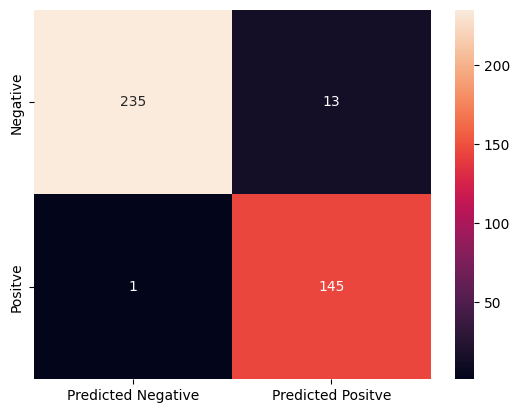

In [66]:
plot_confusion_matrix(y_train, y_train_pred)

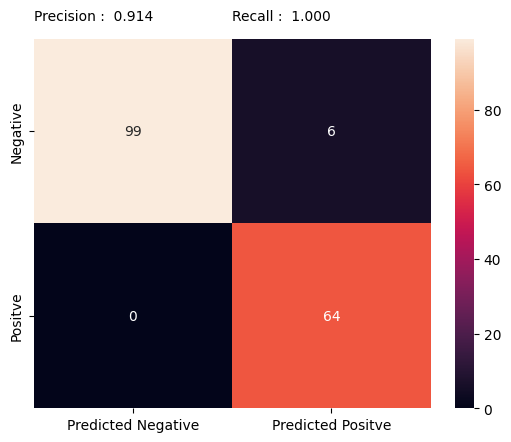

In [69]:
plot_confusion_matrix(y_test, y_test_pred, show_precision_recall=True)

## Lastly we check the ROC

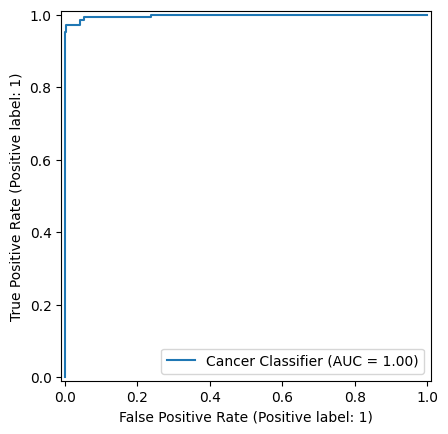

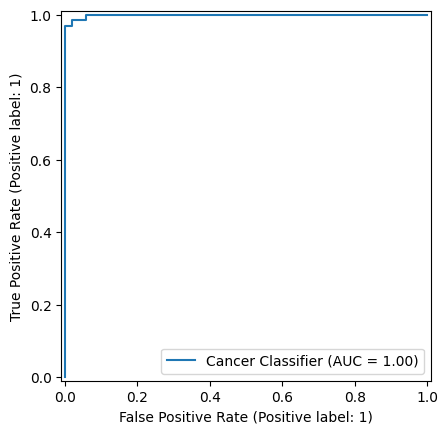

In [76]:
RocCurveDisplay.from_estimator(model, X_train, y_train, name="Cancer Classifier")
plt.show()
RocCurveDisplay.from_estimator(model, X_test, y_test, name="Cancer Classifier")
plt.show()

# Now let's see how our model behave on a new dataset

In [86]:
newData = pd.read_csv("https://raw.githubusercontent.com/ProfAI/machine-learning-fondamenti/refs/heads/main/datasets/breast_cancer_pred.csv")

In [87]:
X = newData.drop(["ID number"], axis=1).values

X = ss.transform(X)

y_proba = model.predict_proba(X)
y_pred = np.where(y_proba[:, 1] > 0.25, 1, 0)

In [90]:
df_results = pd.DataFrame({
    "ID number": newData["ID number"],
    "Prediction": y_pred,
    "Probability": y_proba.max(axis=1).round(4)
})

In [91]:
df_results

,ID number,Prediction,Probability
0,842302,1,1.0000
1,8510426,0,0.8775
2,8510653,0,0.9952
3,8510824,0,1.0000
4,859487,0,0.9982
